# Two-Way Functional ANOVA (F-ANOVA) Example  
## Group × Speed Effects on Response Magnitude Over Time

This notebook demonstrates how to perform a **two-way Functional Analysis of Variance (F-ANOVA)** using the `functionalANOVA` Python package.

---

## Overview

We analyze a functional response measured continuously over **Time (seconds)** under a **2 × 4 factorial design**:

### Primary Factor — Group
- Control  
- Treatment  

### Secondary Factor — Speed
- Slow  
- Normal  
- Fast  
- Very Fast  

Each observation consists of an entire response trajectory across time, allowing statistical inference on full functions rather than single summary values.

---

## Objectives

This script:

1. **Loads functional data** from MATLAB `.mat` files  
2. **Defines the experimental design structure**
3. **Initializes the Functional ANOVA model**
4. **Performs bootstrap-based two-way inference**
5. **Tests for:**
   - Primary main effect (Group)
   - Secondary main effect (Speed)
   - Interaction effect (Group × Speed)
6. **Visualizes mean functional trajectories** and interaction effects

---

## Statistical Model

The two-way functional ANOVA model can be expressed as:

$$
Y_{ijk}(t) = \mu(t) + \alpha_i(t) + \beta_j(t) + (\alpha\beta)_{ij}(t) + \varepsilon_{ijk}(t)
$$

Where:

- $Y_{ijk}(t)$ is the functional response over time  
- $\mu(t)$ is the overall mean function  
- $\alpha_i(t)$ is the primary (Group) effect  
- $\beta_j(t)$ is the secondary (Speed) effect  
- $(\alpha\beta)_{ij}(t)$ is the interaction effect  
- $\varepsilon_{ijk}(t)$ is the residual error function  

Inference is performed using bootstrap resampling.

---

## Why Functional ANOVA?

Unlike classical ANOVA applied to scalar summaries, Functional ANOVA:

- Preserves the full temporal structure of the data  
- Detects differences across the entire domain  
- Identifies interaction effects that vary over time  
- Provides inference on whole trajectories  

---

This notebook provides a complete demonstration of two-way functional inference using the `functionalANOVA` package.

In [34]:
from scipy.io import loadmat
import os
import numpy as np
import pandas as pd
from functionalANOVA.fanova import functionalANOVA

In [ ]:
################################################
# Import statistically significant Data (Family or Secondary Factor Only)

# Import Data
matlab_data = loadmat("../Data/example_data.mat")

# Get data out of .mat file
groups = [matlab_data['TwoWayData'][0, 0], matlab_data['TwoWayData'][0, 1]]
time = matlab_data['timeData']
indicator_list = [matlab_data['IndicatorCell'][0,0], matlab_data['IndicatorCell'][0,1]]

In [ ]:
# # Bounds on time
bounds = (-np.inf, np.inf)
n_boot = 1000 # Default it 10,000 (small for tutorial examples)
seed = 1
myANOVA = functionalANOVA(data_list=groups,
                          d_grid=time,
                          grid_bounds=bounds,
                          subgroup_indicator=indicator_list,
                          n_boot=n_boot,
                          primary_labels=["Control", "Treatment"],
                          secondary_labels = ["Slow", "Normal", "Fast", "Very Fast"],
                          domain_label='Time',
                          domain_units='seconds',
                          response_label="Measurement Value",
                          response_units="a.u.")

## Hypothesis Testing Options

The `twoway()` method supports multiple hypothesis settings depending on which effects you want to test.

---

### Default: `hypothesis="FAMILY"`

This is the default setting.

For a two-way design, `"FAMILY"` performs a joint (family-wise) test of:

- Primary main effect ($\alpha_i(t)$)
- Secondary main effect ($\beta_j(t)$)
- Interaction effect ($( \alpha\beta )_{ij}(t)$)

This evaluates the full two-way model, including interaction terms.

---

### `hypothesis="PRIMARY"`

Tests only the primary main effect:

- Evaluates whether functional means differ across **Group**
- Tests $\alpha_i(t)$
- Does not test secondary or interaction effects

---

### `hypothesis="SECONDARY"`

Tests only the secondary main effect:

- Evaluates whether functional means differ across **Speed**
- Tests $\beta_j(t)$
- Does not test primary or interaction effects

---

### `hypothesis="INTERACTION"`

Tests only the interaction effect:

- Evaluates whether the effect of Speed depends on Group
- Tests $(\alpha\beta)_{ij}(t)$
- Does not independently test main effects

---

### `hypothesis="PAIRWISE"`

Performs pairwise functional comparisons between factor levels.

Depending on the design, this may include:

- Pairwise comparisons between levels of the primary factor  
- Pairwise comparisons between levels of the secondary factor  
- Pairwise comparisons across primary–secondary combinations  

Pairwise testing allows identification of *which specific groups differ*, rather than only determining whether a global main or interaction effect exists.

---

## Summary

| Hypothesis Option | Primary | Secondary | Interaction | Pairwise Comparisons |
|------------------|---------|-----------|-------------|----------------------|
| `"FAMILY"` (default) | ✓ | ✓ | ✓ | — |
| `"PRIMARY"` | ✓ | — | — | — |
| `"SECONDARY"` | — | ✓ | — | — |
| `"INTERACTION"` | — | — | ✓ | — |
| `"PAIRWISE"` | — | — | — | ✓ |

This flexibility allows targeted inference depending on the scientific question of interest.

In [ ]:
myANOVA.twoway(hypothesis="FAMILY", seed=1)  # hypothesis="FAMILY" is default 

Family or Interaction 

In [ ]:
myANOVA.twoway(hypothesis="INTERACTION", seed=1)

In [ ]:
myANOVA.plot_means(plot_type='INTERACTION');

In [ ]:
myANOVA.plot_covariances(plot_type='INTERACTION');

## Plotting Behavior for Two-Way F-ANOVA

### Interaction vs. Family Plots

For a two-way design, the `"INTERACTION"` and `"FAMILY"` hypothesis settings produce the **same mean and covariance plots**.

### Why?

Both settings require visualization of the full set of factor-level combinations:

$$
\text{Mean}_{ij}(t), \quad i = 1,\dots,A,\; j = 1,\dots,B
$$

$$
\text{Cov}_{ij}(s,t), \quad i = 1,\dots,A,\; j = 1,\dots,B
$$

There is no meaningful way to plot an *interaction-only* mean or covariance function because:

- Interaction effects represent **deviations from additive main effects**
- They are **contrasts**, not standalone group processes
- They are defined relative to both primary and secondary effects
- They do not correspond to directly observed group-level data

Therefore:

- `"FAMILY"` plots the full set of primary × secondary group means and covariances
- `"INTERACTION"` plots the exact same group-level means and covariances

The difference between these two settings lies in **the hypothesis being tested**, not in the plotted functions.

---

## Plot Behavior Summary

| Hypothesis      | Mean Plot Displayed                                 | Covariance Plot Displayed                                  |
|-----------------|-----------------------------------------------------|-------------------------------------------------------------|
| `"FAMILY"`      | All primary × secondary group means                 | All primary × secondary group covariances                   |
| `"INTERACTION"` | Same as `"FAMILY"`                                  | Same as `"FAMILY"`                                          |
| `"PRIMARY"`     | Means collapsed over secondary levels               | Covariances pooled over secondary levels                    |
| `"SECONDARY"`   | Means collapsed over primary levels                 | Covariances pooled over primary levels                      |

---

## Key Principle

- The visualization shows **what exists in the data** (empirical group processes).
- The hypothesis setting determines **what statistical contrast is being tested**.
- Hypotheses affect inference, not the empirical group-level functions.

Primary Factor

In [ ]:
myANOVA.twoway(hypothesis="PRIMARY", seed=1)

In [ ]:
myANOVA.plot_means(plot_type='PRIMARY');

In [ ]:
myANOVA.plot_covariances(plot_type='PRIMARY');

Secondary Factor Only

In [ ]:
myANOVA.twoway(hypothesis="SECONDARY", seed=1)

In [ ]:
myANOVA.plot_means(plot_type='SECONDARY');

In [ ]:
myANOVA.plot_covariances(plot_type='SECONDARY');

Pairwise

### `hypothesis="PAIRWISE"`

Performs pairwise functional comparisons between factor-level combinations.

In a two-way design with:

- $A$ primary factor levels  
- $B$ secondary factor levels  

There are $A \times B$ total factor combinations.

Pairwise testing compares all possible combinations of these groups, resulting in:

$$
\binom{A \times B}{2}
$$

total functional hypothesis tests.

For example, in a 2 × 4 design:

- Total groups = $2 \times 4 = 8$
- Total pairwise comparisons = $\binom{8}{2} = 28$

This can result in **many simultaneous functional tests**, so appropriate multiple-comparison control is typically required.

Pairwise testing allows identification of *which specific functional groups differ*, rather than only determining whether global main or interaction effects exist.

In [ ]:
myANOVA.twoway(hypothesis="PAIRWISE", seed=1)

In [42]:
# Same Data just different indicator data type
indicator_array = matlab_data['Master_Indicator']
myANOVA = functionalANOVA(data_list=groups, d_grid=time, grid_bounds=bounds, subgroup_indicator=indicator_array)

levels, counts = np.unique(indicator_array, return_counts=True)

print("\nIndicator Summary")
print("-----------------")
print(f"Shape: {indicator_array.shape}")
print(f"Levels: {[int(x) for x in levels]}")
print(f"Counts: {dict(zip([int(x) for x in levels], [int(n) for n in counts]))}")



Indicator Summary
-----------------
Shape: (120, 1)
Levels: [1, 2, 3, 4]
Counts: {1: 30, 2: 30, 3: 30, 4: 30}


## Non-Statistically Significant Example

In this two-way functional ANOVA example, the family-wise hypothesis test fails to reject the null hypothesis at the 95% confidence level.

All primary, secondary, and interaction effects are statistically non-significant.  
Although minor visual differences appear among the group mean functions, these differences are attributable to sampling variability rather than systematic factor effects.

Calculating, Family-wise, Bootstrap F-type test: 100%|██████████| 1000/1000 [00:02<00:00, 375.19it/s]



Two-Way homoskedastic F-ANOVA Data Summary:

Hypothesis Type = FAMILY
Confidence Level = 95.000 %
Number of Observations Total = 120
Number of Points in Domain = 2501
Number of Groups within Primary Factor = 2
Number of Groups within Secondary Factor= 4
Number of Total Groups = 8
Domain Range = [0.000, 25.000]
Domain Subset = [-inf, inf]
Primary Factor Observation Size: [60, 60]
Secondary Factor Observation Size: [[15 15 15 15], [15 15 15 15]]
Primary Factor Labels: [1, 2]
Secondary Factor Labels: [A, B, C, D]


  Family-Wise Method Test-Statistic P-Value                         Verdict
0           L2-Simul      9680.7566  0.9350  Fail to Reject Null Hypothesis
1           L2-Naive      9680.7566  0.9245  Fail to Reject Null Hypothesis
2     L2-BiasReduced      9680.7566  0.9255  Fail to Reject Null Hypothesis
3       L2-Bootstrap      9680.7566  0.8970  Fail to Reject Null Hypothesis
4            F-Simul         0.5858  0.9282  Fail to Reject Null Hypothesis
5            F-Naive     

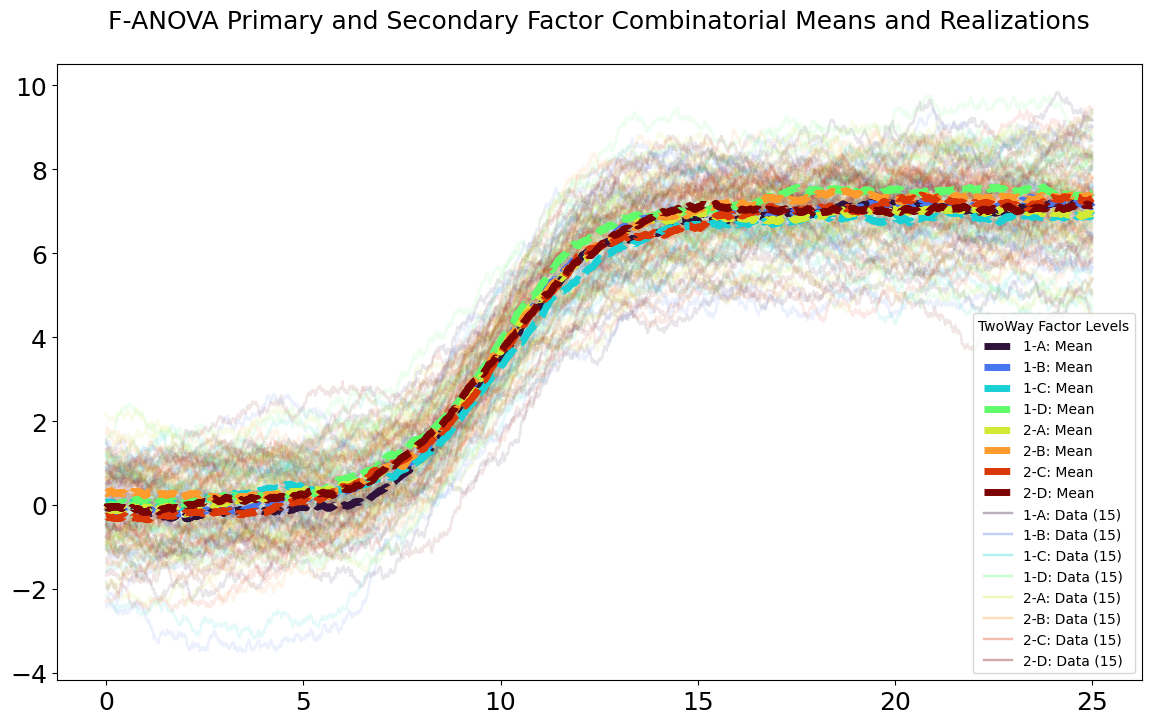

In [43]:
# Import non-statistically significant Data

Datamatlab_data = loadmat("../Data/example_data_2.mat") 
groups = [Datamatlab_data['TwoWayData'][0, 0], Datamatlab_data['TwoWayData'][0, 1]]
time = Datamatlab_data['timeData']
indicator_array = Datamatlab_data['Master_Indicator']
myANOVA_2 = functionalANOVA(data_list=groups, d_grid=time, grid_bounds=bounds, subgroup_indicator=indicator_array, n_boot=n_boot)
myANOVA_2.twoway(seed=1)
myANOVA_2.plot_means();
